# Sleep Stage Classification Notebook

This notebook mirrors the workflow in `final_proj.py`.

In [26]:
!pip install mne
!pip install yasa
!pip install catboost
!pip install lightgbm

In [27]:
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import numpy as np
import mne
import pandas as pd
from yasa import Hypnogram
from pathlib import Path

## RON DID THESE IMPORTS

import lightgbm as lgb

from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')
import catboost as cb
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

try:
    import xgboost as xgb
    print("XGBoost imported successfully!")
except ImportError:
    print("XGBoost not installed. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb
    print("XGBoost installed and imported successfully!")

from xgboost import XGBClassifier
## END RON IMPORTS

XGBoost imported successfully!


## Data Loading

Update the working directory if your EDF files live somewhere else.

In [28]:
# Create raw object from PSG edf data
# raw has diff channels, number of time points, time points, and duration of the data
# ch_names, n_times, times, duration
# Two EEG channels that will be our main data to determine sleep stages
# One EOG and one EMG useful for identifying REM sleep
# --------------------------------------------------EXCLUDE---------------------------------------------------------------
# Resp oro-nasal is used to identify sleep apneas and hypopneas
# temp rectal is body temp useful for identifying sleep quality and sleep onset (wake to sleep)
# Event markers is specific to how each study was ran I think

## Created a variable for the project destination since it will be different for everyone
project_destination = Path.cwd()

# SC Files (Healthy)
raw1 = mne.io.read_raw_edf(f'{project_destination}/SC4001E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw1.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw2 = mne.io.read_raw_edf(f'{project_destination}/SC4002E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw2.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw3 = mne.io.read_raw_edf(f'{project_destination}/SC4011E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw3.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw4 = mne.io.read_raw_edf(f'{project_destination}/SC4012E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw4.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw5 = mne.io.read_raw_edf(f'{project_destination}/SC4022E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw5.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

# ST Files (Symptomatic)
raw_st1 = mne.io.read_raw_edf(f'{project_destination}/ST7011J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw_st1.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw_st2 = mne.io.read_raw_edf(f'{project_destination}/ST7012J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw_st2.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

raw_st3 = mne.io.read_raw_edf(f'{project_destination}/ST7022J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
raw_st3.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

## Testing data not used for training the model, just to see how it performs on new data
# SC Test
test_raw1 = mne.io.read_raw_edf(f'{project_destination}/SC4021E0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
test_raw1.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

# ST Test
test_raw2 = mne.io.read_raw_edf(f'{project_destination}/ST7021J0-PSG.edf', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'))
test_raw2.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})

Extracting EDF parameters from /content/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4002E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4011E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4012E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/SC4022E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7011J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7012J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from /content/ST7022J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


<RawEDF | ST7021J0-PSG.edf, 5 x 3060000 (30600.0 s), ~9 KiB, data not loaded>

## Annotations

In [29]:
# the hypnogram.edf file only has annotations, must add to raw data
ann1 = mne.read_annotations(f'{project_destination}/SC4001EC-Hypnogram.edf')
raw1.set_annotations(ann1)

ann2 = mne.read_annotations(f'{project_destination}/SC4002EC-Hypnogram.edf')
raw2.set_annotations(ann2)

ann3 = mne.read_annotations(f'{project_destination}/SC4011EH-Hypnogram.edf')
raw3.set_annotations(ann3)

ann4 = mne.read_annotations(f'{project_destination}/SC4012EC-Hypnogram.edf')
raw4.set_annotations(ann4)

ann5 = mne.read_annotations(f'{project_destination}/SC4022EJ-Hypnogram.edf')
raw5.set_annotations(ann5)

ann_st1 = mne.read_annotations(f'{project_destination}/ST7011JP-Hypnogram.edf')
raw_st1.set_annotations(ann_st1)

# Assuming ST7012 has a hypnogram, omit if not present. There is ST7041JO but no ST7012 in the list, so I'll just use the available ones or skip if missing. We'll add the ones we know exist.
# Just concatenating the raw data we successfully annotated

## For the test data
test_ann1 = mne.read_annotations(f'{project_destination}/SC4021EH-Hypnogram.edf')
test_raw1.set_annotations(test_ann1)

test_ann2 = mne.read_annotations(f'{project_destination}/ST7021JM-Hypnogram.edf')
test_raw2.set_annotations(test_ann2)

# Pick common channels to avoid nchan mismatch error during concatenation
common_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
raws_to_concat = [raw1, raw2, raw3, raw4, raw5, raw_st1]
for r in raws_to_concat:
    r.pick(common_channels)

raw = mne.concatenate_raws(raws_to_concat) # Data used to train the model
raw.resample(100.0, npad='auto')  # lower sampling rate before epoching to speed processing

# Epoch object has an (X,Y,Z) numpy matrix
# X: number of epochs (each epoch is 30 seconds as specified below)
# Y: number of channels (the EDF data has 4 channels)
# Z: data points in the 30 second intervals
epochs = mne.make_fixed_length_epochs(raw, duration=30.0, preload=True)

psd = epochs.compute_psd(fmin=0.5, fmax=30, picks=['eeg', 'eog', 'emg'])

Sampling frequency of the instance is already 100.0, returning unmodified.
Not setting metadata
15084 matching events found
No baseline correction applied
0 projection items activated
Loading data for 15084 events and 3000 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows


## Labeling

In [30]:
##  NEW WAY THAT MATCHES EPOCHS TO ANNOTATIONS
def stage_at_time(t, ann):
    idx = np.where((ann.onset <= t) & (t < ann.onset + ann.duration))[0]
    return ann.description[idx[0]] if len(idx) else None

epoch_midpoints = np.arange(len(epochs)) * 30.0 + 15.0
labels = [stage_at_time(t, raw.annotations) for t in epoch_midpoints]
##

# encoding hypnogram labels
class_map = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
}

X = epochs.get_data()
Y = np.array([class_map.get(i,i) for i in labels])

print(X.shape)
print(Y.shape)

(15084, 4, 3000)
(15084,)


## Feature Extraction + Model

In [48]:
from sklearn.model_selection import GroupKFold
import mne
import numpy as np
import pandas as pd

## XGBoost Classifier with GroupKFold
# Re-extract features by reloading the raw objects.
# mne.concatenate_raws() modified `raw1` in-place, which caused data leakage when iterating over `raws_to_concat`.

subject_features = []
common_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

raw_configs = [
    ('SC4001E0-PSG.edf', 'SC4001EC-Hypnogram.edf'),
    ('SC4002E0-PSG.edf', 'SC4002EC-Hypnogram.edf'),
    ('SC4011E0-PSG.edf', 'SC4011EH-Hypnogram.edf'),
    ('SC4012E0-PSG.edf', 'SC4012EC-Hypnogram.edf'),
    ('SC4022E0-PSG.edf', 'SC4022EJ-Hypnogram.edf'),
    ('ST7011J0-PSG.edf', 'ST7011JP-Hypnogram.edf')
]

for subj_idx, (psg_file, hyp_file) in enumerate(raw_configs):
    # Epoch each subject individually from scratch to safely track IDs
    r = mne.io.read_raw_edf(f'{project_destination}/{psg_file}', exclude=('Resp oro-nasal', 'Temp rectal','Event marker'), preload=True, verbose=False)
    r.set_channel_types({'EOG horizontal':'eog','EMG submental':'emg'})
    ann = mne.read_annotations(f'{project_destination}/{hyp_file}')
    r.set_annotations(ann)
    r.pick(common_channels)
    r.resample(100.0, npad='auto')

    subj_epochs = mne.make_fixed_length_epochs(r, duration=30.0, preload=True, verbose=False)
    X_data = subj_epochs.get_data()
    epoch_midpoints = np.arange(len(subj_epochs)) * 30.0 + 15.0
    epoch_labels = [stage_at_time(t, r.annotations) for t in epoch_midpoints]

    for idx, epoch in enumerate(X_data):
        lbl = epoch_labels[idx]
        if lbl in class_map:
            row = {'time': epoch_midpoints[idx], 'subject_id': subj_idx, 'label': class_map[lbl]}
            for ch_idx, ch_name in enumerate(subj_epochs.ch_names):
                data = epoch[ch_idx]
                prefix = ch_name.replace(' ', '_').replace('-', '_')
                row[f'{prefix}_mean'] = data.mean()
                row[f'{prefix}_std'] = data.std()
                row[f'{prefix}_min'] = data.min()
                row[f'{prefix}_max'] = data.max()
            subject_features.append(row)

features_df = pd.DataFrame(subject_features)
TRAINING_FEATURE_COLUMNS = features_df.drop(columns=['time', 'subject_id', 'label']).columns.tolist()

X = features_df[TRAINING_FEATURE_COLUMNS]
y = features_df['label'].values
groups = features_df['subject_id'].values

## Cross-validation with XGBoost and GroupKFold (Leakage-Free)
gkf = GroupKFold(n_splits=5)
cv_model = XGBClassifier(eval_metric='mlogloss', random_state=42)

scores = cross_val_score(cv_model, X, y, cv=gkf, groups=groups, scoring='accuracy')
print('Leakage-Free GroupKFold CV scores: ', scores)
print('Mean CV accuracy: ', scores.mean())

# Train a final model on all data for future unseen testing (if needed)
cv_model.fit(X, y)


Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Leakage-Free GroupKFold CV scores:  [0.86622191 0.88723931 0.91470378 0.90635209 0.74505612]
Mean CV accuracy:  0.8639146414273171


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Testing

In [52]:
# Testing model on new data set (test_raw1 and test_ann1)
def evaluate_test_raw(test_raw_obj, model):
    # Fix: explicitly pick the common channels so extra channels (like 'Marker') don't cause feature mismatch
    common_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
    test_raw_obj.pick(common_channels)

    test_epochs = mne.make_fixed_length_epochs(test_raw_obj, duration=30.0, preload=True)
    test_epoch_midpoints = np.arange(len(test_epochs)) * 30.0 + 15.0
    test_labels = [stage_at_time(t, test_raw_obj.annotations) for t in test_epoch_midpoints]

    test_valid_mask = np.array([lbl in class_map for lbl in test_labels])
    test_X_data = test_epochs.get_data()[test_valid_mask]
    test_y_true = np.array([class_map[lbl] for lbl in test_labels if lbl in class_map], dtype=int)
    test_times = test_epoch_midpoints[test_valid_mask]

    test_feature_rows = []
    for idx, epoch in enumerate(test_X_data):
        row = {'time': test_times[idx]}
        for ch_idx, ch_name in enumerate(test_epochs.ch_names):
            data = epoch[ch_idx]
            prefix = ch_name.replace(' ', '_').replace('-', '_')
            row[f'{prefix}_mean'] = data.mean()
            row[f'{prefix}_std'] = data.std()
            row[f'{prefix}_min'] = data.min()
            row[f'{prefix}_max'] = data.max()
        test_feature_rows.append(row)

    test_features_df = pd.DataFrame(test_feature_rows)
    test_y_pred = model.predict(test_features_df.drop(columns=['time']))
    test_accuracy = accuracy_score(test_y_true, test_y_pred)
    return test_accuracy, test_epochs, test_y_true, test_y_pred, test_X_data

test_accuracy_sc, test_epochs, test_y, test_y_pred, test_X_data = evaluate_test_raw(test_raw1, cv_model)
print(f'SC Test Accuracy: {test_accuracy_sc:.4f}')

test_accuracy_st, _, test_y_st, _, test_X_data_st = evaluate_test_raw(test_raw2, cv_model)
print(f'ST Test Accuracy: {test_accuracy_st:.4f}')

Not setting metadata
2804 matching events found
No baseline correction applied
0 projection items activated
Loading data for 2804 events and 3000 original time points ...
0 bad epochs dropped
SC Test Accuracy: 0.8916
Not setting metadata
1020 matching events found
No baseline correction applied
0 projection items activated
Loading data for 1020 events and 3000 original time points ...
0 bad epochs dropped
ST Test Accuracy: 0.6326


## Hypnogram

(2804,)
(2804,)


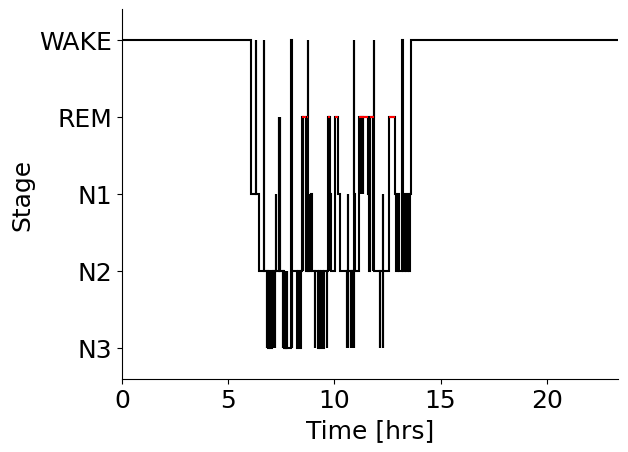

In [36]:
# ------------------------------------------HYPNOGRAM CREATION-------------------------------------
# replace annotations (strings) with integers for yasa.from_integers function
#true_hypnogram = np.array([class_map.get(i,i) for i in test_ann1.description])

# replace unknown sleep stages with
#true_hypnogram = [-2 if x == 'Sleep stage ?' else x for x in true_hypnogram]

print(test_y_pred.shape)
print(test_y.shape)
#print(len(true_hypnogram))

# plot correct hypnogram
hyp2 = Hypnogram.from_integers(test_y) # or use test_y_pred to see model predicted hypnogram
hyp2.plot_hypnogram()
plt.savefig("SampleHypnogram.png")
plt.show()

### Full Hypnogram and Epoch Detail
This visualization shows the complete sleep progression across the entire recording, paired with a detailed view of a single epoch.

## Confusion Matrix

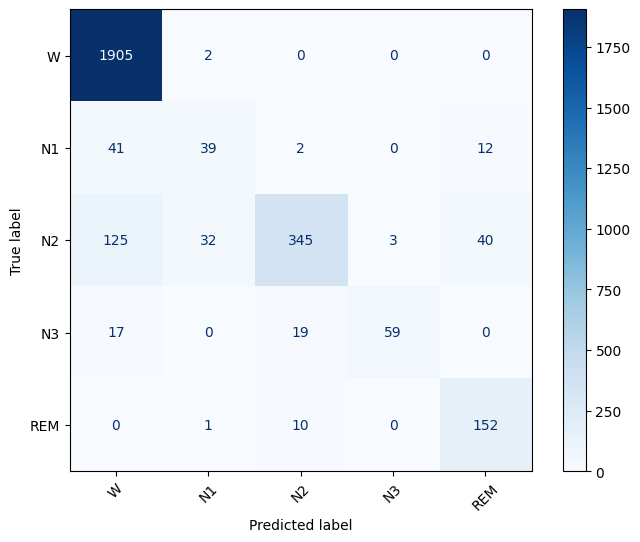

In [38]:
# ------------------------------------------CONFUSION MATRIX-------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_y, test_y_pred)
classes = np.unique(np.concatenate([test_y, test_y_pred]))

stage_names = {
    0: 'W',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'REM'
}
labels = [stage_names[c] for c in classes]

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.show()

    Using multitaper spectrum estimation with 7 DPSS windows


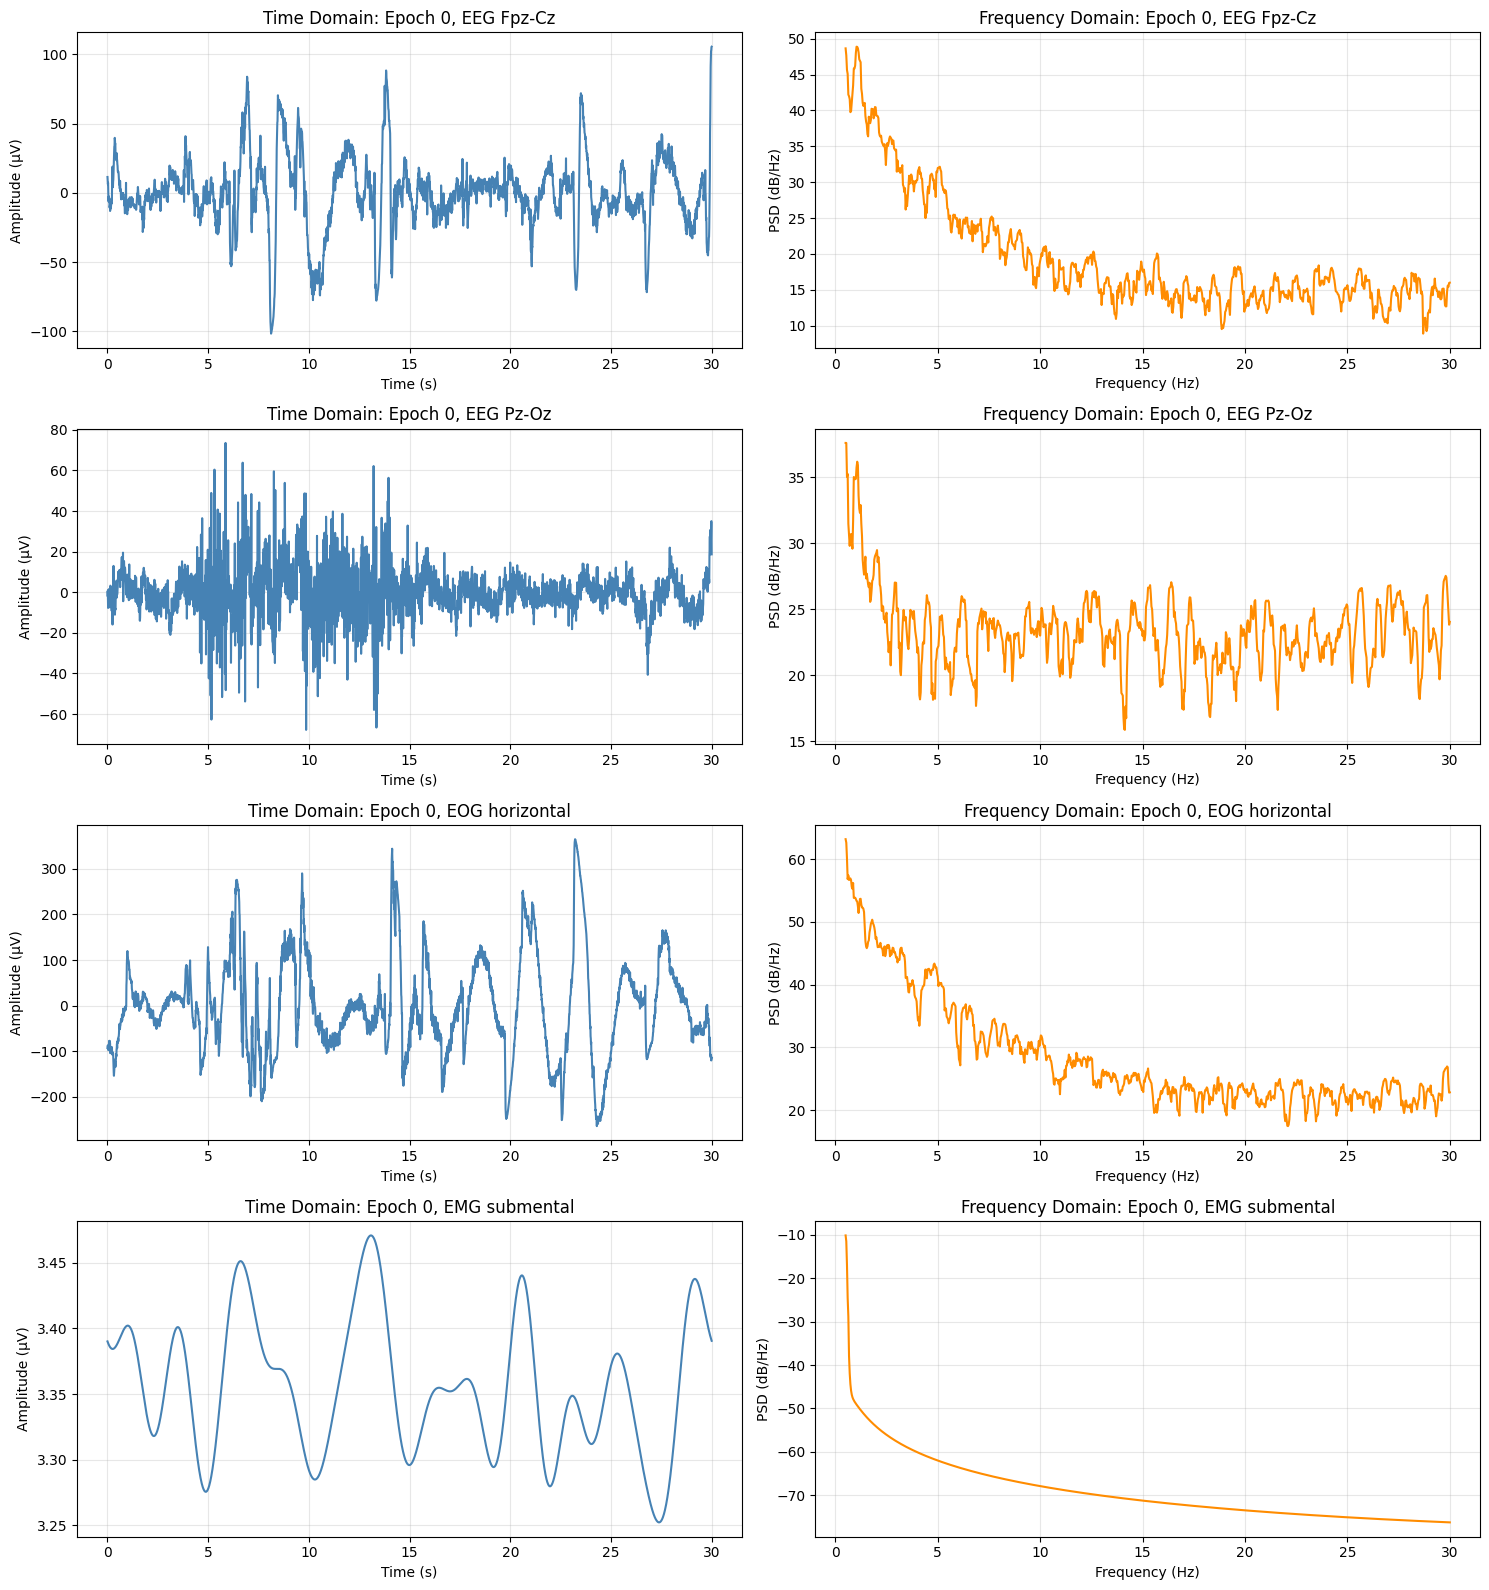

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Select a specific epoch for visualization
epoch_idx = 0
test_psd = test_epochs.compute_psd(fmin=0.5, fmax=30, picks=['eeg', 'eog', 'emg'])
ch_names = test_psd.ch_names
n_channels = len(ch_names)

# Create subplots: n_channels rows, 2 columns
fig, axes = plt.subplots(n_channels, 2, figsize=(15, 4 * n_channels))

for i, ch_name in enumerate(ch_names):
    # 1. Time Domain Data (Before PSD)
    # Explicitly pick the channel to avoid mismatched shapes
    time_data = test_epochs.get_data(picks=ch_name)[epoch_idx, 0, :]
    times = test_epochs.times

    # 2. Frequency Domain Data (After PSD)
    psd_data = test_psd.get_data(picks=ch_name)[epoch_idx, 0, :]
    freqs = test_psd.freqs

    ax1 = axes[i, 0] if n_channels > 1 else axes[0]
    ax2 = axes[i, 1] if n_channels > 1 else axes[1]

    # Plot Time Domain
    ax1.plot(times, time_data * 1e6, color='steelblue') # Convert to uV for readability
    ax1.set_title(f"Time Domain: Epoch {epoch_idx}, {ch_name}")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude (µV)")
    ax1.grid(True, alpha=0.3)

    # Plot Frequency Domain (PSD)
    # Convert power to decibels (dB) for standard PSD visualization
    psd_db = 10 * np.log10(psd_data * 1e12) # Scale appropriately for uV^2/Hz
    ax2.plot(freqs, psd_db, color='darkorange')
    ax2.set_title(f"Frequency Domain: Epoch {epoch_idx}, {ch_name}")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("PSD (dB/Hz)")
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Detailed Epoch Visualization
This cell plots a single 30-second epoch to show the signal characteristics in detail.

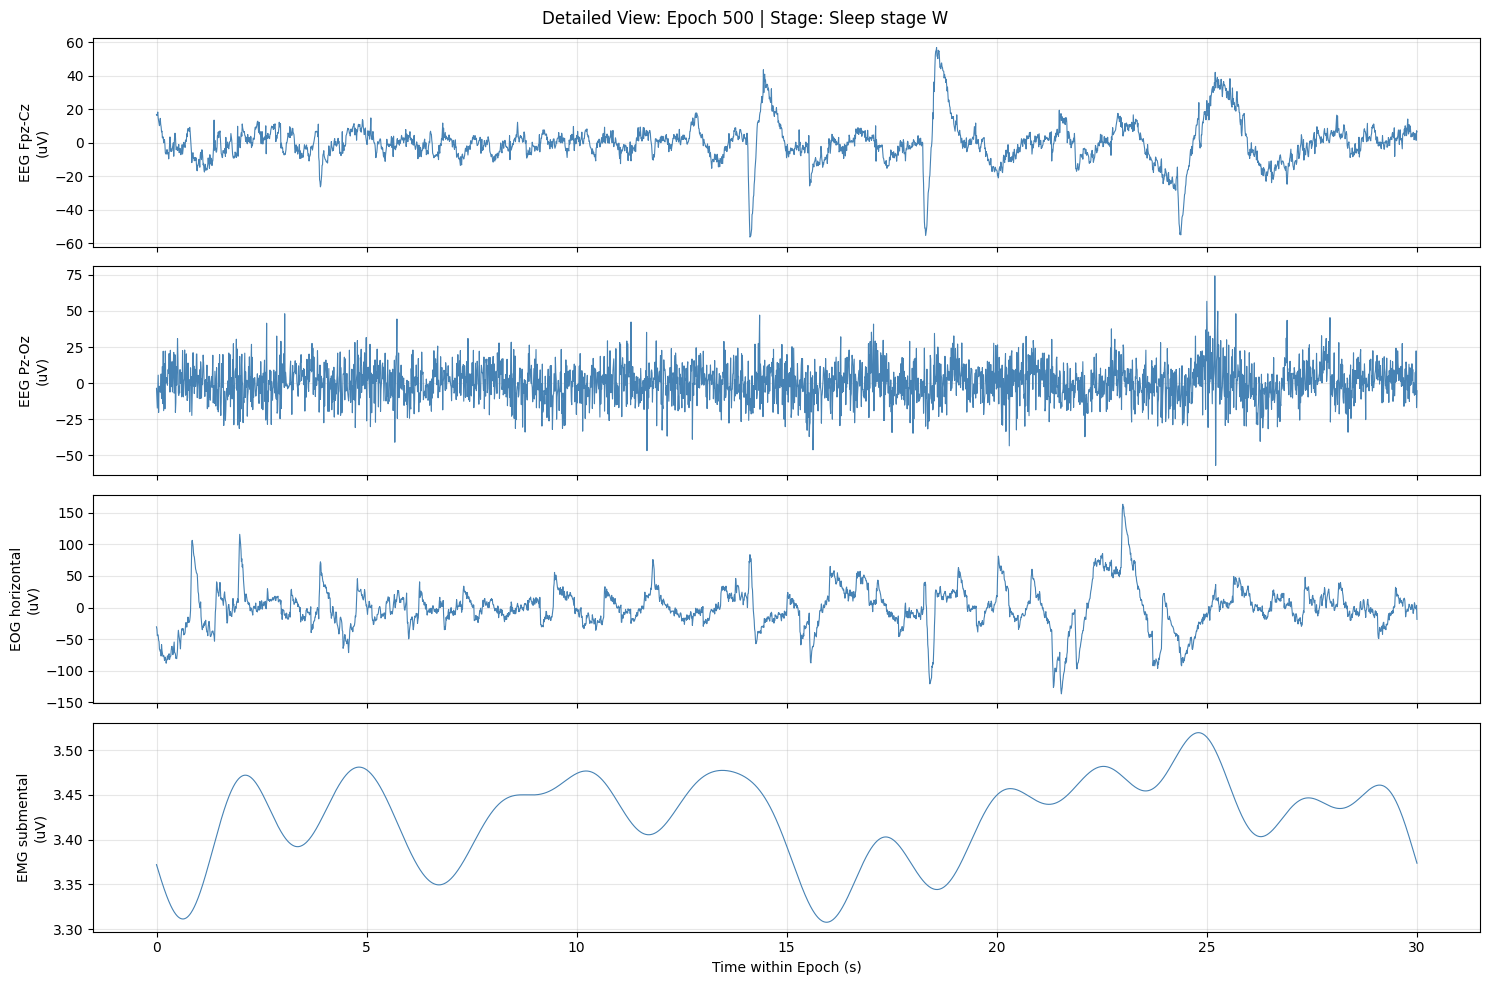

In [40]:
import matplotlib.pyplot as plt

# Let's pick an epoch that isn't just 'Wake' (Stage 0)
# We'll look at epoch 500 as an example
epoch_idx = 500
epoch_data = test_epochs.get_data()[epoch_idx]
epoch_label = test_labels[epoch_idx]

fig, axes = plt.subplots(len(test_epochs.ch_names), 1, figsize=(15, 10), sharex=True)

# Sampling frequency and time array for 30 seconds
sf = test_epochs.info['sfreq']
time_axis = np.linspace(0, 30, epoch_data.shape[1])

for i, (data, ch_name) in enumerate(zip(epoch_data, test_epochs.ch_names)):
    axes[i].plot(time_axis, data * 1e6, color='steelblue', lw=0.8)
    axes[i].set_ylabel(f"{ch_name}\n(uV)")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time within Epoch (s)")
plt.suptitle(f"Detailed View: Epoch {epoch_idx} | Stage: {epoch_label}")
plt.tight_layout()
plt.savefig("ExampleEpoch.png")
plt.show()

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SleepHybridNet(nn.Module):
    def __init__(self, num_channels=4, num_classes=5, d_model=64, nhead=4, num_layers=2):
        super(SleepHybridNet, self).__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            # extract high-frequency local features
            nn.Conv1d(in_channels=num_channels, out_channels=32, kernel_size=50, stride=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            #  extract broader contextual features
            nn.Conv1d(in_channels=32, out_channels=d_model, kernel_size=8, stride=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=3)
        )

        # The Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # x shape: (B, 4, 3000)

        # Extract features
        features = self.cnn(x)
        # features shape: (B, d_model, Sequence_Length)

        features = features.permute(0, 2, 1)

        transformer_out = self.transformer(features)

        pooled = torch.mean(transformer_out, dim=1)

        out = self.classifier(pooled)
        return out

model = SleepHybridNet()
print(model)

SleepHybridNet(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(50,), stride=(5,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm

In [54]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# NOTE: The training metrics below reflect in-sample performance only as this
# current PyTorch split lacks subject-aware cross-validation (GroupKFold).

X_train_raw = epochs.get_data()

epoch_mids = np.arange(len(epochs)) * 30.0 + 15.0
correct_labels = [stage_at_time(t, raw.annotations) for t in epoch_mids]

Y_train_raw = np.array([class_map.get(i, i) for i in correct_labels])

valid_mask = [isinstance(lbl, int) for lbl in Y_train_raw]
X_train = X_train_raw[valid_mask]
Y_train = Y_train_raw[valid_mask].astype(int)

B, C, L = X_train.shape
# Transpose and flatten to (B*L, C) so the scaler sees 4 features (the channels)
X_train_reshaped = X_train.transpose(0, 2, 1).reshape(-1, C)
X_train_scaled = scaler.fit_transform(X_train_reshaped)
# Reshape back to (B, C, L)
X_train_scaled = X_train_scaled.reshape(B, L, C).transpose(0, 2, 1)
X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_tensor = torch.tensor(Y_train, dtype=torch.long)

dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

Using device: cuda


In [50]:
import torch.optim as optim

model = SleepHybridNet(num_channels=4, num_classes=5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs_to_train = 30

print("Starting training...")
for epoch in range(epochs_to_train):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_Y in train_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_Y.size(0)
        correct += (predicted == batch_Y).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs_to_train} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

Starting training...
Epoch 1/30 - Loss: 0.3810 - Accuracy: 87.36%
Epoch 2/30 - Loss: 0.2270 - Accuracy: 92.24%
Epoch 3/30 - Loss: 0.2070 - Accuracy: 92.42%
Epoch 4/30 - Loss: 0.1892 - Accuracy: 93.19%
Epoch 5/30 - Loss: 0.1757 - Accuracy: 93.60%
Epoch 6/30 - Loss: 0.1695 - Accuracy: 93.63%
Epoch 7/30 - Loss: 0.1572 - Accuracy: 94.28%
Epoch 8/30 - Loss: 0.1558 - Accuracy: 94.19%
Epoch 9/30 - Loss: 0.1508 - Accuracy: 94.45%
Epoch 10/30 - Loss: 0.1512 - Accuracy: 94.45%
Epoch 11/30 - Loss: 0.1484 - Accuracy: 94.64%
Epoch 12/30 - Loss: 0.1416 - Accuracy: 94.72%
Epoch 13/30 - Loss: 0.1344 - Accuracy: 94.96%
Epoch 14/30 - Loss: 0.1271 - Accuracy: 95.02%
Epoch 15/30 - Loss: 0.1253 - Accuracy: 95.43%
Epoch 16/30 - Loss: 0.1276 - Accuracy: 95.25%
Epoch 17/30 - Loss: 0.1179 - Accuracy: 95.59%
Epoch 18/30 - Loss: 0.1133 - Accuracy: 95.58%
Epoch 19/30 - Loss: 0.1118 - Accuracy: 95.52%
Epoch 20/30 - Loss: 0.1090 - Accuracy: 95.88%
Epoch 21/30 - Loss: 0.1040 - Accuracy: 96.11%
Epoch 22/30 - Loss: 0.

Starting Out-of-Sample Evaluation...
Test Loss: 0.2339
Test Accuracy: 93.79%

Classification Report:
              precision    recall  f1-score   support

    Wake (0)       0.98      1.00      0.99      1907
      N1 (1)       0.45      0.54      0.49        94
      N2 (2)       0.90      0.88      0.89       545
    Deep (3)       0.78      0.77      0.78        95
     REM (4)       0.92      0.74      0.82       163

    accuracy                           0.94      2804
   macro avg       0.81      0.79      0.79      2804
weighted avg       0.94      0.94      0.94      2804



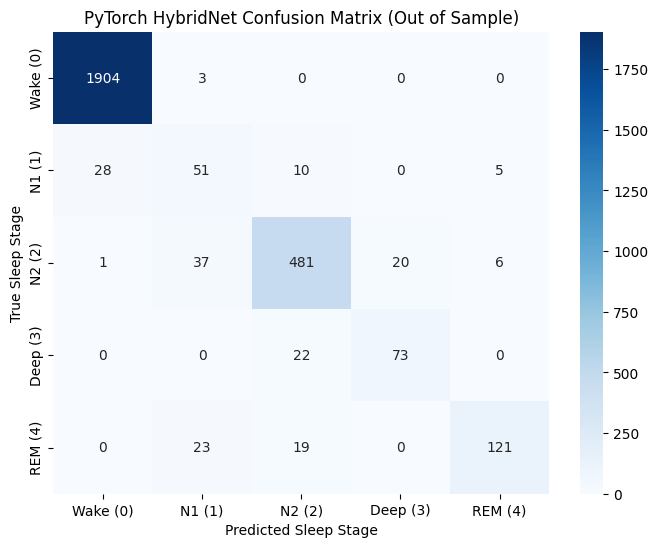

In [51]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

B_test, C_test, L_test = test_X_data.shape

X_test_scaled = scaler.transform(test_X_data.reshape(B_test, C_test * L_test)).reshape(B_test, C_test, L_test)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(test_y, dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
test_loss = 0.0
all_preds = []
all_targets = []

print("Starting Out-of-Sample Evaluation...")

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        test_loss += loss.item() * batch_X.size(0)

        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_Y.cpu().numpy())

avg_test_loss = test_loss / len(test_dataset)
test_acc = 100 * sum([p == t for p, t in zip(all_preds, all_targets)]) / len(all_targets)

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%\n")

print("Classification Report:")
target_names = ['Wake (0)', 'N1 (1)', 'N2 (2)', 'Deep (3)', 'REM (4)']
print(classification_report(all_targets, all_preds, target_names=target_names))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('PyTorch HybridNet Confusion Matrix (Out of Sample)')
plt.ylabel('True Sleep Stage')
plt.xlabel('Predicted Sleep Stage')
plt.show()

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Extracting subject-aware epochs...")
X_list, y_list, group_list = [], [], []

for subj_idx, (psg_file, hyp_file) in enumerate(raw_configs):
    r = mne.io.read_raw_edf(f'{project_destination}/{psg_file}', exclude=('Resp oro-nasal', 'Temp rectal', 'Event marker'), preload=True, verbose=False)
    r.set_channel_types({'EOG horizontal': 'eog', 'EMG submental': 'emg'})
    ann = mne.read_annotations(f'{project_destination}/{hyp_file}')
    r.set_annotations(ann)
    r.pick(common_channels)
    r.resample(100.0, npad='auto')

    subj_epochs = mne.make_fixed_length_epochs(r, duration=30.0, preload=True, verbose=False)
    X_data = subj_epochs.get_data()
    epoch_midpoints = np.arange(len(subj_epochs)) * 30.0 + 15.0
    epoch_labels = [stage_at_time(t, r.annotations) for t in epoch_midpoints]

    for idx, epoch in enumerate(X_data):
        lbl = epoch_labels[idx]
        if lbl in class_map:
            X_list.append(epoch)
            y_list.append(class_map[lbl])
            group_list.append(subj_idx) # Track the subject ID!

X_all = np.array(X_list)
y_all = np.array(y_list)
groups_all = np.array(group_list)

# Handle Class Imbalance
classes = np.unique(y_all)
# Computes weights inversely proportional to class frequencies
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_all)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Calculated Class Weights: {weights}")

#  GroupKFold Training Loop with Early Stopping
gkf = GroupKFold(n_splits=5)
epochs_to_train = 30


for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups_all)):
    print(f"\n================ Fold {fold + 1} ================")

    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    scaler = StandardScaler()
    B_tr, C, L = X_train.shape
    X_train_reshaped = X_train.transpose(0, 2, 1).reshape(-1, C)
    X_train_scaled = scaler.fit_transform(X_train_reshaped).reshape(B_tr, L, C).transpose(0, 2, 1)

    B_val = X_val.shape[0]
    X_val_reshaped = X_val.transpose(0, 2, 1).reshape(-1, C)
    X_val_scaled = scaler.transform(X_val_reshaped).reshape(B_val, L, C).transpose(0, 2, 1)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                                            torch.tensor(y_train, dtype=torch.long)),
                              batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                                          torch.tensor(y_val, dtype=torch.long)),
                            batch_size=64, shuffle=False)

    model = SleepHybridNet(num_channels=4, num_classes=5).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs_to_train):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

        avg_train_loss = train_loss / train_total
        avg_val_loss = val_loss / val_total
        val_acc = 100 * val_correct / val_total

        print(f"Epoch {epoch+1:02d}/{epochs_to_train} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Using device: cuda
Extracting subject-aware epochs...
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Sampling frequency of the instance is already 100.0, returning unmodified.
Calculated Class Weights: [0.31080212 4.96716418 1.07896254 3.07831449 3.03465046]

================ Fold 1 ================
Epoch 01/30 | Train Loss: 0.7130 | Val Loss: 0.4492 | Val Acc: 78.62%
Epoch 02/30 | Train Loss: 0.4760 | Val Loss: 0.3707 | Val Acc: 82.76%
Epoch 03/30 | Train Loss: 0.4466 | Val Loss: 0.4125 | Val Acc: 85.71%
Epoch 04/30 | Train Loss: 0.4121 | Val Loss: 0.3976 | Val Acc: 81.71%
Epoch 05/30 | Train Loss: 0.3685 | Val Loss: 0.3630 | Val Acc: 86.13%
Epoch 06/30 | Train L